[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[11:16:59] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

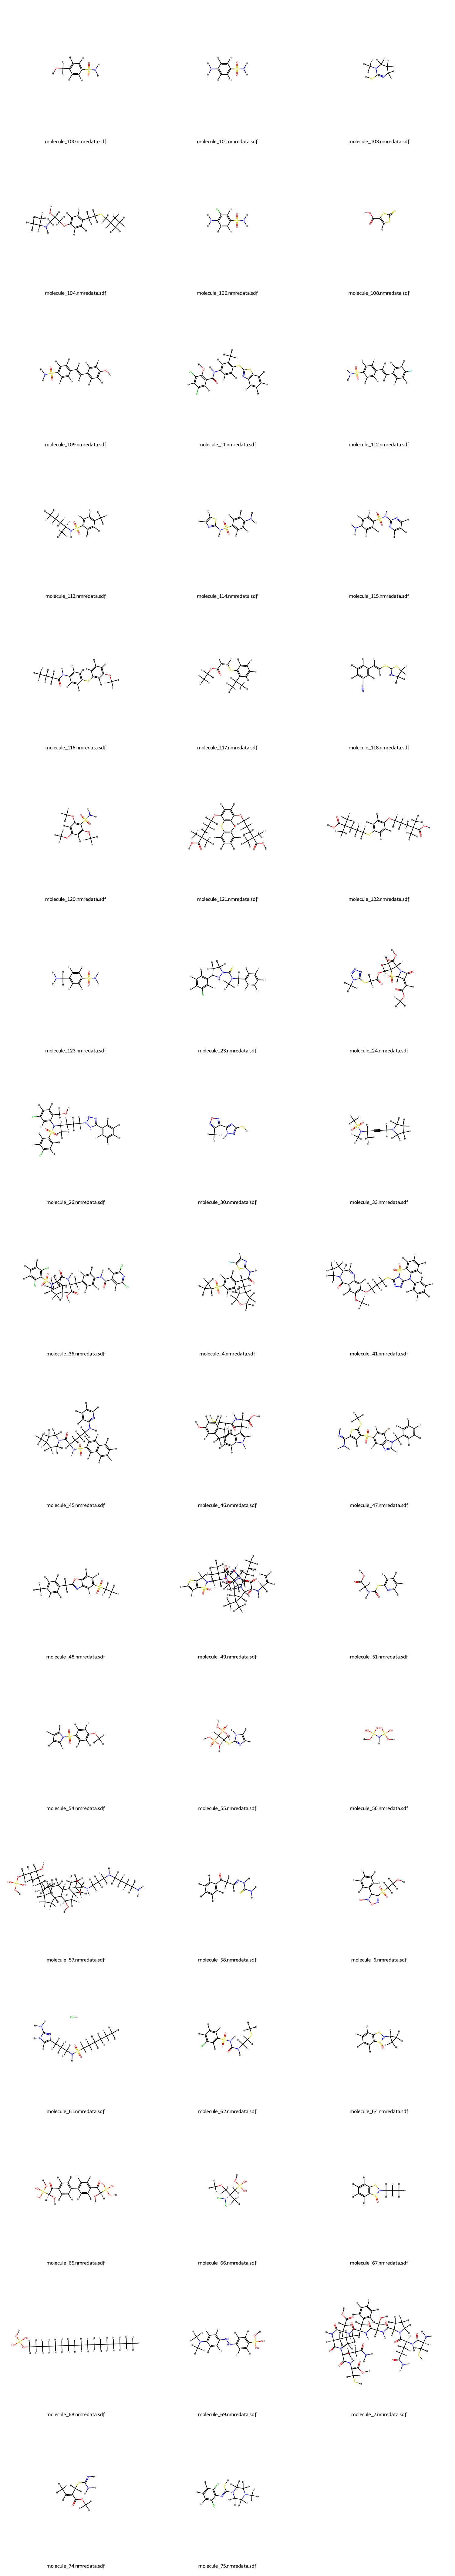

In [ ]:
import os
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display 

# folder path
folder_path = r"C:\Project_code\OUTPUT\90%"
sdf_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".sdf")]

# Load molecules
molecules = []
molecule_names = []  

for sdf_file in sdf_files:
    suppl = Chem.SDMolSupplier(sdf_file, removeHs=False)
    for mol in suppl:
        if mol:
            Chem.rdDepictor.Compute2DCoords(mol)  # Convert 3D to 2D
            molecules.append(mol)
            molecule_names.append(os.path.basename(sdf_file))  # Store filename

if not molecules:
    print("No valid molecules found in the SDF files.")
else:
    # Generate a grid image with molecule names
    img = Draw.MolsToGridImage(
        molecules,
        molsPerRow=3,
        subImgSize=(500, 500),
        legends=molecule_names  # Displays file names under molecules
    )

    display(img) # Display is the goat


In [29]:
# Need to remove white space between images and lowkey format with 7 per row

import os
import re
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from PIL import Image, ImageDraw, ImageFont
import io

# folder path
folder_path = r"C:\Project_code\OUTPUT\90%"
sdf_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".sdf")]

# Extract numbers from filenames 
def extract_number(filename):
    match = re.search(r"(\d+)", filename) 
    return int(match.group(1)) if match else float('inf')

# Sort files numerically
sdf_files.sort(key=lambda x: extract_number(os.path.basename(x)))

molecules = []
molecule_names = []

for sdf_file in sdf_files:
    suppl = Chem.SDMolSupplier(sdf_file, removeHs=False)
    for mol in suppl:
        if mol:
            rdDepictor.Compute2DCoords(mol)  # 2D coordinates
            molecules.append(mol)

            # Format
            base_name = os.path.basename(sdf_file)
            molecule_number = extract_number(base_name)
            molecule_names.append(f"Molecule {molecule_number}")

# check
if not molecules:
    print("No valid molecules found in the SDF files.")
else:
    # Define grid layout
    num_cols = 7  
    num_rows = (len(molecules) + num_cols - 1) // num_cols  
    mol_size = (300, 300)  
    label_height = 50  

    # Load Times New Roman font 
    try:
        font = ImageFont.truetype("times.ttf", 28)  
    except IOError:
        font = ImageFont.load_default()

    # Generate images
    mol_images = []
    for i, mol in enumerate(molecules):
        drawer = rdMolDraw2D.MolDraw2DCairo(mol_size[0], mol_size[1])
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()

        img_bytes = drawer.GetDrawingText()
        img = Image.open(io.BytesIO(img_bytes))  #bytes to an image
        img = img.convert("RGB")  

        #molecule name below image
        labeled_img = Image.new("RGB", (mol_size[0], mol_size[1] + label_height), "white")
        labeled_img.paste(img, (0, 0))

        # Draw text
        draw = ImageDraw.Draw(labeled_img)
        text = molecule_names[i]
        text_width, text_height = draw.textbbox((0, 0), text, font=font)[2:]  
        text_x = (mol_size[0] - text_width) // 2 
        draw.text((text_x, mol_size[1] + 10), text, fill="black", font=font)  

        mol_images.append(labeled_img)

    #grid
    grid_width = num_cols * mol_size[0]
    grid_height = num_rows * (mol_size[1] + label_height)
    final_img = Image.new("RGB", (grid_width, grid_height), "white")

    #  molecule images into the grid
    for i, img in enumerate(mol_images):
        row, col = divmod(i, num_cols)
        x = col * mol_size[0]
        y = row * (mol_size[1] + label_height)
        final_img.paste(img, (x, y))

    # Display
    final_img.show()

    final_img.save("7_in_row_molecules_grid.png")

[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Explicit valence for atom # 18 N, 4, is greater than permitted
[12:03:52] ERROR: Could not sanitize molecule ending on line 106
[12:03:52] ERROR: Explicit valence for atom # 18 N, 4, is greater than permitted
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[12:03:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 